In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#df = pd.read_csv('inputs/All_external.csv')

C:\Users\Ceci\AppData\Local\Temp\ipykernel_9736\3907431521.py:1: DtypeWarning: Columns (2,4,5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('inputs/All_external.csv')


In [4]:
df = pd.read_csv(
    'inputs/All_external.csv',
    dtype={
        'Stock_symbol': 'string',
        'Publisher': 'string',
        'Author': 'string',
        'Article': 'string'
    }
)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13057514 entries, 0 to 13057513
Data columns (total 11 columns):
 #   Column            Dtype  
---  ------            -----  
 0   Date              object 
 1   Article_title     object 
 2   Stock_symbol      string 
 3   Url               object 
 4   Publisher         string 
 5   Author            string 
 6   Article           string 
 7   Lsa_summary       float64
 8   Luhn_summary      float64
 9   Textrank_summary  float64
 10  Lexrank_summary   float64
dtypes: float64(4), object(3), string(4)
memory usage: 1.1+ GB


In [7]:
df.head()

,Date,Article_title,Stock_symbol,Url,Publisher,Author,Article,Lsa_summary,Luhn_summary,Textrank_summary,Lexrank_summary
0,2020-06-05 06:30:54 UTC,Stocks That Hit 52-Week Highs On Friday,A,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,<NA>,<NA>,NaN,NaN,NaN,NaN
1,2020-06-03 06:45:20 UTC,Stocks That Hit 52-Week Highs On Wednesday,A,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,<NA>,<NA>,NaN,NaN,NaN,NaN
2,2020-05-26 00:30:07 UTC,71 Biggest Movers From Friday,A,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,<NA>,<NA>,NaN,NaN,NaN,NaN
3,2020-05-22 08:45:06 UTC,46 Stocks Moving In Friday's Mid-Day Session,A,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,<NA>,<NA>,NaN,NaN,NaN,NaN
4,2020-05-22 07:38:59 UTC,B of A Securities Maintains Neutral on Agilent...,A,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,<NA>,<NA>,NaN,NaN,NaN,NaN


In [8]:
df.isna().any()


Date                False
Article_title        True
Stock_symbol         True
Url                  True
Publisher            True
Author               True
Article              True
Lsa_summary          True
Luhn_summary         True
Textrank_summary     True
Lexrank_summary      True
dtype: bool

In [9]:
df.isna().sum()


Date                       0
Article_title              1
Stock_symbol         9804627
Url                      686
Publisher            9030871
Author              11871199
Article             11809202
Lsa_summary         13057514
Luhn_summary        13057514
Textrank_summary    13057514
Lexrank_summary     13057514
dtype: int64

In [ ]:
# tenemos el título de (casi) todos los artículos
# tenemos la gran mayoría de las urls
# tenemos el stock symbol en 3.252.887
# tenemos el publisher en 4.026.643
# tenemos el texto del artículo en 1.248.312



#Lsa_summary, Luhn_summary, Textrank_summary y Lexrank_summary son null para todos los regisros
#¿Son el output del análisis que ellos realizan?

In [13]:
mask = df[['Article_title', 'Stock_symbol', 'Publisher', 'Article']].notna().all(axis=1)
count_non_nulls = mask.sum()
print("Registros con todos los campos no nulos:", count_non_nulls)


Registros con todos los campos no nulos: 0


In [14]:
mask = df[['Article_title', 'Stock_symbol', 'Article']].notna().all(axis=1)
count_non_nulls = mask.sum()
print("Registros con todos los campos no nulos:", count_non_nulls)

Registros con todos los campos no nulos: 0


In [15]:
mask = df[['Article_title', 'Publisher', 'Article']].notna().all(axis=1)
count_non_nulls = mask.sum() 
print("Registros con todos los campos no nulos:", count_non_nulls)

Registros con todos los campos no nulos: 773751


In [16]:
mask = df[['Article_title', 'Stock_symbol', 'Publisher']].notna().all(axis=1)
count_non_nulls = mask.sum()
print("Registros con todos los campos no nulos:", count_non_nulls)

Registros con todos los campos no nulos: 3252887


In [41]:
df[df[['Article_title', 'Stock_symbol', 'Publisher']].notna().all(axis=1)].head(10)

,Date,Article_title,Stock_symbol,Url,Publisher,Author,Article
0,2020-06-05 06:30:54 UTC,Stocks That Hit 52-Week Highs On Friday,A,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,<NA>,<NA>
1,2020-06-03 06:45:20 UTC,Stocks That Hit 52-Week Highs On Wednesday,A,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,<NA>,<NA>
2,2020-05-26 00:30:07 UTC,71 Biggest Movers From Friday,A,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,<NA>,<NA>
3,2020-05-22 08:45:06 UTC,46 Stocks Moving In Friday's Mid-Day Session,A,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,<NA>,<NA>
4,2020-05-22 07:38:59 UTC,B of A Securities Maintains Neutral on Agilent...,A,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,<NA>,<NA>
5,2020-05-22 07:23:25 UTC,"CFRA Maintains Hold on Agilent Technologies, L...",A,https://www.benzinga.com/news/20/05/16095163/c...,vishwanath@benzinga.com,<NA>,<NA>
6,2020-05-22 05:36:20 UTC,"UBS Maintains Neutral on Agilent Technologies,...",A,https://www.benzinga.com/news/20/05/16094027/u...,vishwanath@benzinga.com,<NA>,<NA>
7,2020-05-22 05:07:04 UTC,Agilent Technologies shares are trading higher...,A,https://www.benzinga.com/wiim/20/05/16093805/a...,Benzinga Newsdesk,<NA>,<NA>
8,2020-05-22 04:37:59 UTC,Wells Fargo Maintains Overweight on Agilent Te...,A,https://www.benzinga.com/news/20/05/16093505/w...,vishwanath@benzinga.com,<NA>,<NA>
9,2020-05-22 04:06:17 UTC,10 Biggest Price Target Changes For Friday,A,https://www.benzinga.com/analyst-ratings/price...,Lisa Levin,<NA>,<NA>


In [42]:
df[df[['Article_title', 'Stock_symbol', 'Publisher']].notna().all(axis=1)].head(10)['Article_title'][5]

'CFRA Maintains Hold on Agilent Technologies, Lowers Price Target to $85'

In [ ]:
#Recorto el dataset
#(el foco va a ser trabajar con los registors donde 'Article_title', 'Publisher', 'Article'
#son no nulos)

In [17]:
cols_to_drop = ['Lsa_summary', 'Luhn_summary', 'Textrank_summary', 'Lexrank_summary']
df = df.drop(columns=cols_to_drop)

In [19]:
cols = ['Article_title', 'Publisher', 'Article']
mask = df[cols].notna().all(axis=1)
df_clean = df.loc[mask].copy()

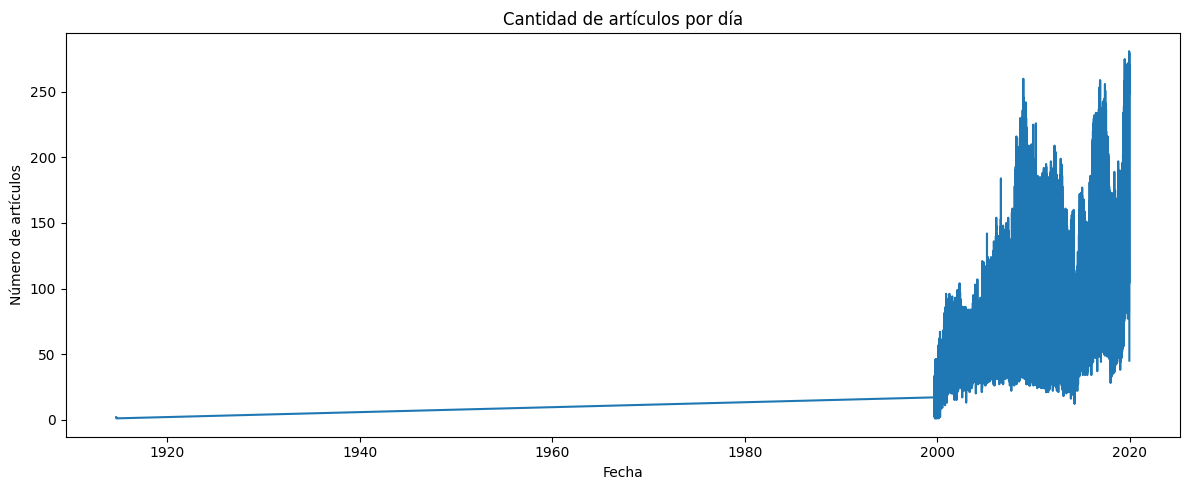

In [20]:
# Convertir la columna Date a tipo datetime
df_clean['Date'] = pd.to_datetime(df_clean['Date'], errors='coerce')

# Agrupar por fecha y contar artículos
articulos_por_dia = df_clean.groupby('Date').size()

# Graficar
plt.figure(figsize=(12, 5))
plt.plot(articulos_por_dia.index, articulos_por_dia.values)
plt.title('Cantidad de artículos por día')
plt.xlabel('Fecha')
plt.ylabel('Número de artículos')
plt.tight_layout()
plt.show()

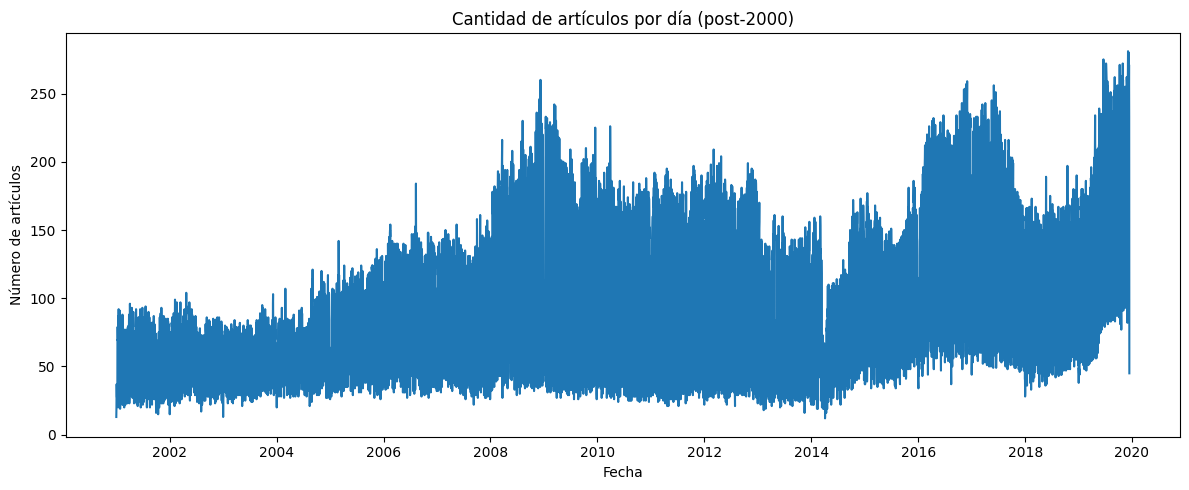

In [43]:
import pandas as pd
import matplotlib.pyplot as plt

# Convertir la columna Date a tipo datetime
df_clean['Date'] = pd.to_datetime(df_clean['Date'], errors='coerce')

# Filtrar solo fechas posteriores al 2000
df_clean = df_clean[df_clean['Date'].dt.year > 2000]

# Agrupar por fecha y contar artículos
articulos_por_dia = df_clean.groupby('Date').size()

# Graficar
plt.figure(figsize=(12, 5))
plt.plot(articulos_por_dia.index, articulos_por_dia.values)
plt.title('Cantidad de artículos por día (post-2000)')
plt.xlabel('Fecha')
plt.ylabel('Número de artículos')
plt.tight_layout()
plt.show()


In [44]:
# Convertir a datetime si no está hecho
df_clean['Date'] = pd.to_datetime(df_clean['Date'], errors='coerce')

# Filtrar años 2000-2020
df_clean = df_clean[(df_clean['Date'].dt.year >= 2000) & (df_clean['Date'].dt.year <= 2020)]

# Agrupar por día y contar artículos
articulos_por_dia = df_clean.groupby('Date').size()

# Crear un índice de fechas completo
fecha_inicio = df_clean['Date'].min()
fecha_fin = df_clean['Date'].max()
fechas_completas = pd.date_range(start=fecha_inicio, end=fecha_fin, freq='D')

# Reindexar para que los días sin artículos aparezcan con 0
articulos_por_dia = articulos_por_dia.reindex(fechas_completas, fill_value=0)


In [28]:
import pandas as pd

# df_clean: tu sub-DataFrame filtrado y con Date tipo datetime
df_clean['Date'] = pd.to_datetime(df_clean['Date'], errors='coerce')

# Filtrar años 2000-2020
df_clean = df_clean[(df_clean['Date'].dt.year >= 2000) & (df_clean['Date'].dt.year <= 2020)]

# Contar artículos por día
articulos_por_dia = df_clean.groupby('Date').size()

# Crear índice de fechas completo
fecha_inicio = df_clean['Date'].min()
fecha_fin = df_clean['Date'].max()
fechas_completas = pd.date_range(start=fecha_inicio, end=fecha_fin, freq='D')

# Reindexar para que los días sin artículos aparezcan con 0
articulos_por_dia = articulos_por_dia.reindex(fechas_completas, fill_value=0)

# Pasar a DataFrame
df_dias = articulos_por_dia.reset_index()
df_dias.columns = ['Date', 'count']

# Crear columna Año-Mes como string
df_dias['YearMonth'] = df_dias['Date'].dt.strftime('%Y-%m')

# Contar días sin artículos por mes, incluyendo meses sin huecos
dias_sin_articulos = df_dias.groupby('YearMonth').apply(lambda x: (x['count'] == 0).sum())

# Mostrar resultados
print(dias_sin_articulos)



YearMonth
2001-01    0
2001-02    0
2001-03    0
2001-04    0
2001-05    0
          ..
2019-08    0
2019-09    0
2019-10    0
2019-11    0
2019-12    0
Length: 228, dtype: int64


C:\Users\Ceci\AppData\Local\Temp\ipykernel_9736\3063758071.py:28: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dias_sin_articulos = df_dias.groupby('YearMonth').apply(lambda x: (x['count'] == 0).sum())


In [45]:
dias_sin_articulos.to_csv('outputs/all_dias_sin_articulos.csv', header=['Dias_sin_articulos'])


In [ ]:
#según esto, desde ene-2001 y dic-2019 hay al menos un artículo cada día

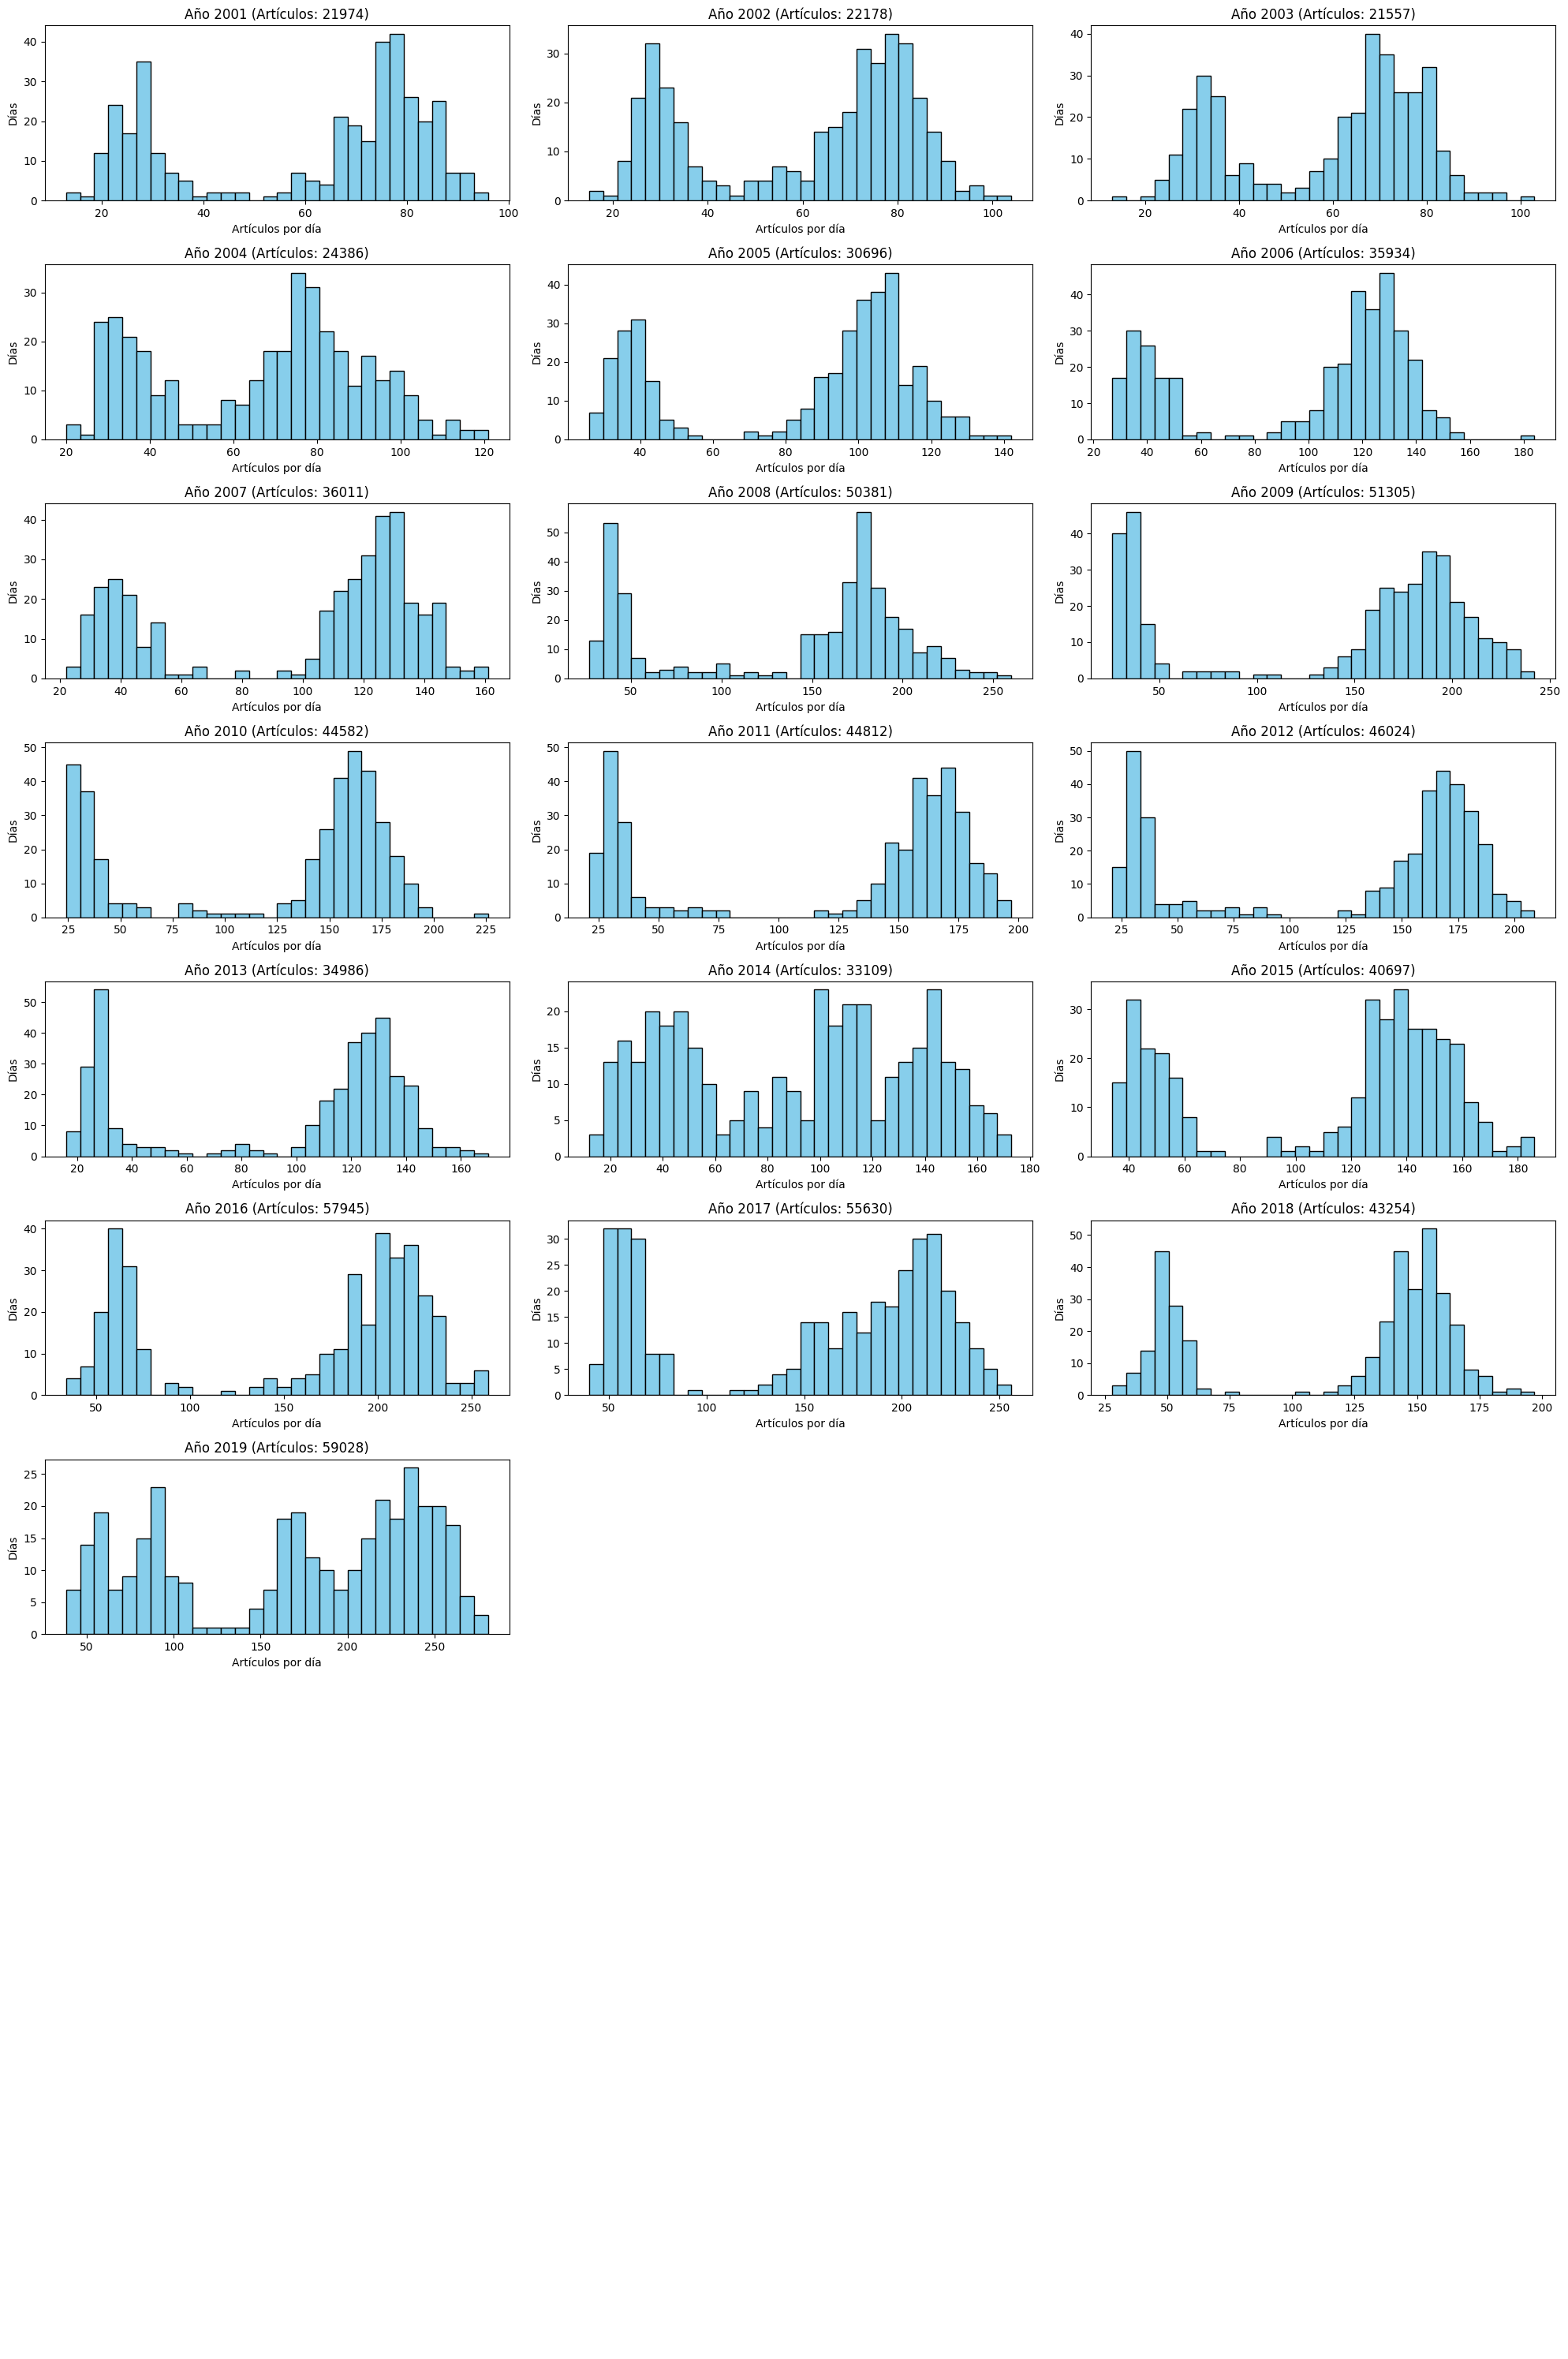

In [34]:

# df_clean: tu sub-DataFrame filtrado con las 3 columnas no nulas
df_clean['Date'] = pd.to_datetime(df_clean['Date'], errors='coerce')
df_clean = df_clean[(df_clean['Date'].dt.year >= 2001) & (df_clean['Date'].dt.year <= 2019)]

# Contar artículos por día
articulos_por_dia = df_clean.groupby('Date').size()

# Crear DataFrame con año
df_dias = articulos_por_dia.reset_index()
df_dias.columns = ['Date', 'count']
df_dias['Year'] = df_dias['Date'].dt.year

# Configuración de subplots: 10 filas x 3 columnas
fig, axes = plt.subplots(nrows=10, ncols=3, figsize=(20, 30), sharex=False, sharey=False)
axes = axes.flatten()

years = range(2001, 2020)
for i, year in enumerate(years):
    ax = axes[i]
    data_year = df_dias[df_dias['Year'] == year]['count']
    
    # Histograma
    ax.hist(data_year, bins=30, color='skyblue', edgecolor='black')
    
    # Contar total de artículos en ese año
    total_articulos = data_year.sum()
    
    # Título con año + total de artículos
    ax.set_title(f'Año {year} (Artículos: {total_articulos})')
    ax.set_xlabel('Artículos por día')
    ax.set_ylabel('Días')
    
# Ocultar subplots sobrantes
for j in range(len(years), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

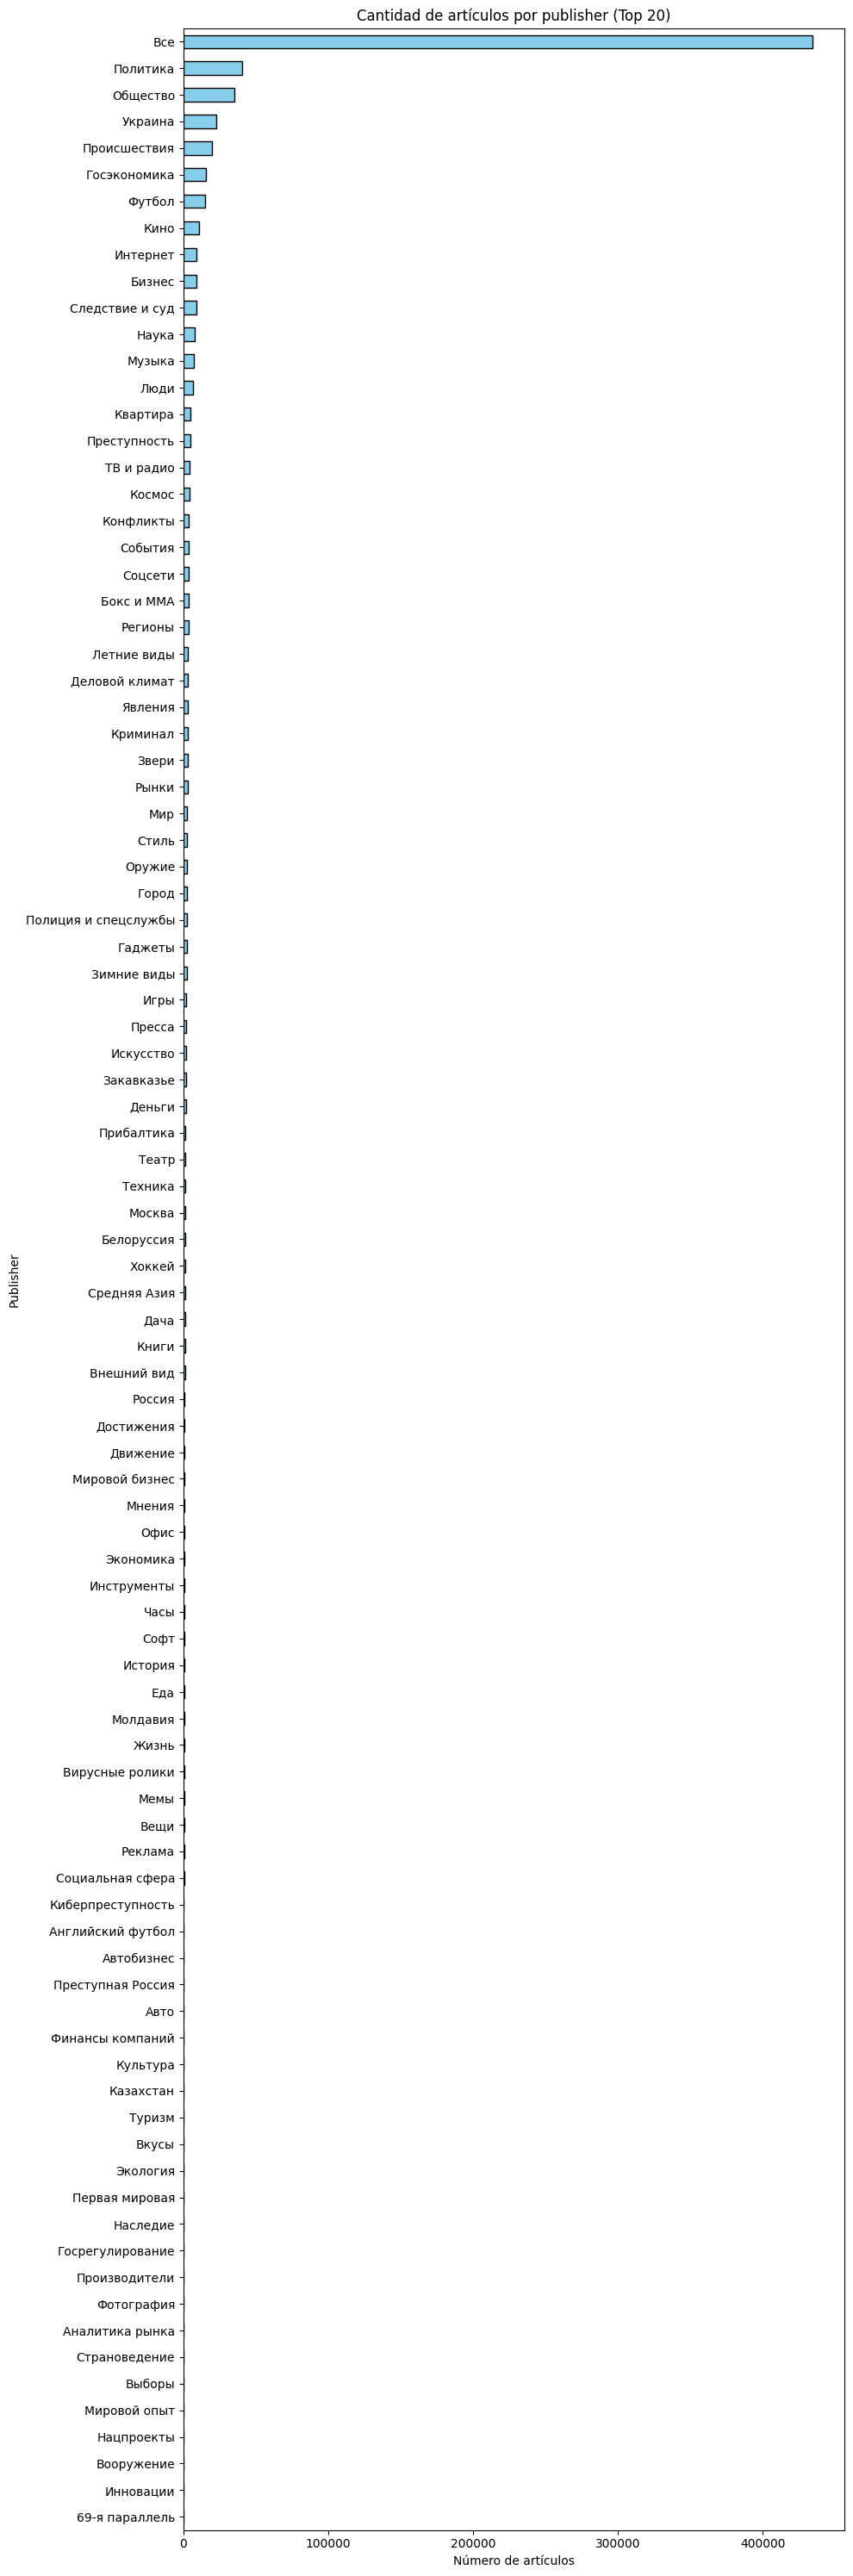

In [38]:
# Contar artículos por Publisher
articulos_por_publisher = df_clean['Publisher'].value_counts()

top_publishers = articulos_por_publisher

# Graficar horizontal
plt.figure(figsize=(10, 30))
top_publishers.plot(kind='barh', color='skyblue', edgecolor='black')
plt.title('Cantidad de artículos por publisher (Top 20)')
plt.xlabel('Número de artículos')
plt.ylabel('Publisher')
plt.gca().invert_yaxis()  # Para que el top 1 quede arriba
plt.tight_layout()
plt.show()


In [39]:
df_clean.head()

,Date,Article_title,Stock_symbol,Url,Publisher,Author,Article
1426590,2001-01-01 00:00:00+00:00,Пожар в жилом доме в центре Москвы ликвидирован,<NA>,https://lenta.ru/news/2001/01/01/fire/,Все,Россия,Пожар в Москве в жилом здании на Новинском бул...
1426591,2001-01-01 00:00:00+00:00,Хоккеисты молодежной сборной России проиграли ...,<NA>,https://lenta.ru/news/2001/01/01/junior/,Все,Спорт,Молодежная сборная России по хоккею не получит...
1426592,2001-01-01 00:00:00+00:00,Российская экономика третьего тысячелетия: нов...,<NA>,https://lenta.ru/news/2001/01/01/newlife/,Все,Экономика,Минимальный размер оплаты труда в России с 1 я...
1426593,2001-01-01 00:00:00+00:00,Кафельников и Южный выигрывают первые матчи се...,<NA>,https://lenta.ru/news/2001/01/01/tennis/,Все,Спорт,В первую неделю нового года начался новый тенн...
1426594,2001-01-01 00:00:00+00:00,Новогодняя петарда устроила пожар на Дворцовой...,<NA>,https://lenta.ru/news/2001/01/01/spb/,Все,Россия,В новогоднюю ночь на Дворцовой площади Санкт-П...
